## PROYECTO FINAL - Clasificación de pacientes con esquizofrenia

Alumnos: Ricardo Amiel y Josué Jeremias

## Estado del pipeline
*(este bloque se actualiza en cada iteración para saber siempre en qué fase estamos)*

**Fase 1 — Preprocesamiento EEG — COMPLETADA Y CONFIRMADA**
- [x] Carga de metadatos y mapeo binario de diagnóstico (sano=0 / esquizofrenia=1)
- [x] Función de preprocesamiento por archivo (filtros 0.5–45 Hz, notch 50 Hz, resample 250 Hz, ventanas 5 s, z-score)
- [x] Armonización de canales por nombre — confirmado: 153/153 sujetos recuperados (77 control / 76 paciente), ventanas balanceadas (2946 vs 3000)
- [x] Split train/val/test a nivel de sujeto — confirmado: 107/23/23 sujetos, balance de clases razonable en cada conjunto (0.53 / 0.44 / 0.44)

**Fase 2 — Transformación a imágenes tiempo-frecuencia — código agregado, pendiente de ejecutar**
- [x] Espectrogramas STFT (función probada, corre correctamente sobre todo X)
- [~] Escalogramas Wavelet: descartados por decisión (cuello de botella de rendimiento); se prioriza FFT/STFT
- [ ] Aplicar split a `X_stft` + normalización log1p/z-score (código listo, falta correr y confirmar)

**Fase 3 — Extracción y selección de características clásicas — código agregado, pendiente de ejecutar**
- [ ] Extracción de características con `tsfresh` (canal por canal, `MinimalFCParameters`)
- [ ] Imputación y selección de características (ajustada solo con train)

**Fase 4 — Entrenamiento de modelos — código agregado, pendiente de ejecutar**
- [ ] Modelos clásicos: SVM, XGBoost, Random Forest, Regresión logística
- [ ] Modelos DL: CNN propia + ResNet18 (transfer learning, conv1 adaptada a 19 canales)
- [ ] (Omitido por alcance) ViT/Swin o EEG-Conformer

**Fase 5 — Comparación experimental final — código agregado, pendiente de ejecutar**
- [ ] Evaluación final en TEST de los 6 modelos
- [ ] Tabla comparativa clásico vs. deep learning
- [ ] Matrices de confusión
- [ ] Conclusiones (plantilla agregada, pendiente de redactar con resultados reales)

Leyenda: `[x]` completado y confirmado · `[~]` completado pero descartado/cambiado de plan · `[ ]` pendiente

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import mne
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# =====================================================================
# 1. PARÁMETROS GENERALES DE PREPROCESAMIENTO CLÍNICO
# =====================================================================
BASE_DATASET_DIR = "./ASZED-153"
CSV_PATH = os.path.join(BASE_DATASET_DIR, "ASZED_SpreadSheet.csv")

FREQ_LOW = 0.5       # Filtro pasa-alta (remueve deriva lenta de los electrodos)
FREQ_HIGH = 45.0     # Filtro pasa-baja (remueve interferencia electromuscular de alta frecuencia)
FREQ_NOTCH = 50.0    # Filtro Notch (remueve el ruido de la línea eléctrica ambiental)
WINDOW_SEC = 5.0     # Tamaño de cada ventana temporal de EEG en segundos
TARGET_SFREQ = 250.0

# [FIX] El dataset ASZED tiene DOS formatos de adquisición distintos:
#   Formato A: 'EEG Fp1-LE', 'EEG C3-LE', ... (20 canales, incluye referencia A2, 256 Hz)
#   Formato B: 'Fp1[1]', 'C3[5]', ... (24 canales, incluye EMG/EOG/Pg1/Pg2, 200-100 Hz)
# Ambos comparten el mismo set de 19 electrodos estándar 10-20. Armonizamos por NOMBRE
# (no por conteo de canales) para no perder ningún sujeto de ninguna clase.
CANONICAL_CHANNELS = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
                       'T3', 'C3', 'Cz', 'C4', 'T4',
                       'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']

def normalize_channel_name(name):
    """Normaliza nombres de canal de ambos formatos de adquisición a la
    convención estándar 10-20: quita prefijo 'EEG ', sufijo '-LE' y
    sufijo numérico '[n]'."""
    n = name.strip()
    n = re.sub(r'^EEG\s+', '', n, flags=re.IGNORECASE)
    n = re.sub(r'-LE$', '', n, flags=re.IGNORECASE)
    n = re.sub(r'\[\d+\]$', '', n)
    return n

print("Librerías cargadas. Configurando pipeline...")


Librerías cargadas. Configurando pipeline...


## Preprocesamiento EEG


### Fase 1. Carga y organización de los registros por sujeto, clase y paradigma experimental.

In [2]:
# =====================================================================
# 2. CARGA Y TRADUCCIÓN BINARIA DE METADATOS
# =====================================================================
mapping_dict = {}

try:
    df_meta = pd.read_csv(CSV_PATH)
    df_meta.columns = df_meta.columns.str.strip()
    df_meta['sn_clean'] = df_meta['sn'].astype(str).str.strip().str.lower()
    df_meta['category_clean'] = df_meta['category'].astype(str).str.strip().str.lower()
    
    # Mapeo binario: 'patient' -> 1 (Esquizofrenia), 'control' -> 0 (Sano)
    df_meta['Diagnosis'] = df_meta['category_clean'].apply(lambda x: 1 if 'patient' in x else 0)
    mapping_dict = dict(zip(df_meta['sn_clean'], df_meta['Diagnosis']))
    
    print(f"[✓] SpreadSheet mapeada con éxito.")
    print(f"    -> Total de sujetos registrados en el CSV maestro: {len(mapping_dict)}")
except Exception as e:
    print(f"[!] Error crítico procesando el archivo CSV: {e}")

[✓] SpreadSheet mapeada con éxito.
    -> Total de sujetos registrados en el CSV maestro: 153


In [3]:
df_meta

,sn,age,gender,category,language,node,sn_clean,category_clean,Diagnosis
0,subject_2,50,F,Patient,Yoruba,OAUTHC_IFE_ILESA,subject_2,patient,1
1,subject_3,45,F,Patient,English,OAUTHC_IFE_ILESA,subject_3,patient,1
2,subject_4,35,M,Patient,English,OAUTHC_IFE_ILESA,subject_4,patient,1
3,subject_5,28,M,Patient,English,OAUTHC_IFE_ILESA,subject_5,patient,1
4,subject_6,39,F,Patient,English,OAUTHC_IFE_ILESA,subject_6,patient,1
...,...,...,...,...,...,...,...,...,...
148,subject_156,44,M,Control,English,OAUTHC_IFE_ILESA,subject_156,control,0
149,subject_157,30,F,Control,English,OAUTHC_IFE_ILESA,subject_157,control,0
150,subject_158,51,M,Control,Yoruba,OAUTHC_IFE_ILESA,subject_158,control,0
151,subject_159,33,F,Control,English,OAUTHC_IFE_ILESA,subject_159,control,0


In [4]:
# =====================================================================
# 3. FUNCIÓN DE PREPROCESAMIENTO CLÍNICO POR ARCHIVO (con armonización de canales)
# =====================================================================
def preprocess_edf_file(edf_path, freq_low, freq_high, freq_notch, window_sec, target_sfreq=250.0):
    """
    Carga señales .edf, ARMONIZA los canales al estándar 10-20 de 19 canales
    (sin importar el formato de adquisición original), remuestrea a frecuencia
    estándar, filtra ruidos y segmenta aplicando normalización Z-score.

    Retorna (windows, sfreq, reason). 'reason' es None si todo salió bien,
    o un string explicando por qué se descartó el archivo.
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        # [FIX] Armonización de nombres de canal entre los dos formatos del dataset
        rename_map = {}
        for ch in raw.ch_names:
            norm = normalize_channel_name(ch)
            for canon in CANONICAL_CHANNELS:
                if norm.lower() == canon.lower():
                    rename_map[ch] = canon
                    break
        raw.rename_channels(rename_map)

        available = [c for c in CANONICAL_CHANNELS if c in raw.ch_names]
        if len(available) < len(CANONICAL_CHANNELS):
            missing = sorted(set(CANONICAL_CHANNELS) - set(available))
            return None, None, f"faltan canales: {missing}"

        # Selecciona EXACTAMENTE los 19 canales estándar, siempre en el mismo orden
        # (descarta de paso EMG/EOG/Pg1/Pg2/A2, que no son señal cortical comparable)
        raw.pick_channels(CANONICAL_CHANNELS, ordered=True)

        if raw.info['sfreq'] != target_sfreq:
            raw.resample(sfreq=target_sfreq, verbose=False)

        raw.filter(l_freq=freq_low, h_freq=freq_high, fir_design='firwin', verbose=False)
        raw.notch_filter(freqs=freq_notch, fir_design='firwin', verbose=False)

        data, times = raw.get_data(return_times=True)
        sfreq = raw.info['sfreq']

        samples_per_window = int(window_sec * sfreq)
        total_samples = data.shape[1]
        num_windows = total_samples // samples_per_window

        if num_windows == 0:
            return None, None, f"registro muy corto ({total_samples} muestras)"

        file_windows = []
        for w in range(num_windows):
            start_idx = w * samples_per_window
            end_idx = start_idx + samples_per_window
            window_data = data[:, start_idx:end_idx]

            # Normalización Z-score por canal
            mean = np.mean(window_data, axis=1, keepdims=True)
            std = np.std(window_data, axis=1, keepdims=True) + 1e-8
            normalized_window = (window_data - mean) / std

            file_windows.append(normalized_window)

        return np.array(file_windows), sfreq, None
    except Exception as e:
        return None, None, f"excepción: {e}"


In [5]:
# =====================================================================
# 4. EXTRACCIÓN Y PROCESAMIENTO RECURSIVO (con canales ya armonizados)
# =====================================================================
from collections import Counter

all_windows = []
all_labels = []
all_subjects = []

# Escaneo dinámico recursivo agnóstico a las carpetas intermedias
subject_folders = glob.glob(os.path.join(BASE_DATASET_DIR, "**", "subject_*"), recursive=True) + \
                  glob.glob(os.path.join(BASE_DATASET_DIR, "**", "Subject_*"), recursive=True)
subject_folders = sorted(list(set(subject_folders)))

print("\n[*] Iniciando carga masiva y procesamiento digital de señales...")

discard_reasons = Counter()
processed_files = 0
expected_shape = (len(CANONICAL_CHANNELS), int(WINDOW_SEC * TARGET_SFREQ))

for sub_folder in subject_folders:
    folder_name = os.path.basename(sub_folder.rstrip(os.sep)).strip().lower()
    label = mapping_dict.get(folder_name, None)

    if label is None:
        continue

    edf_files = glob.glob(os.path.join(sub_folder, "**", "*.edf"), recursive=True) + \
                glob.glob(os.path.join(sub_folder, "**", "*.EDF"), recursive=True)
    edf_files = sorted(list(set(edf_files)))

    try:
        sub_id_int = int(folder_name.split("_")[-1])
    except ValueError:
        sub_id_int = 999

    for edf_path in edf_files:
        processed_files += 1
        windows, sfreq, reason = preprocess_edf_file(edf_path, FREQ_LOW, FREQ_HIGH, FREQ_NOTCH, WINDOW_SEC, TARGET_SFREQ)

        if windows is None:
            discard_reasons[reason] += 1
            continue

        for window in windows:
            # Verificación defensiva: con la armonización de canales esto SIEMPRE debe cumplirse
            assert window.shape == expected_shape, f"Forma inesperada {window.shape} en {edf_path}"
            all_windows.append(window)
            all_labels.append(label)
            all_subjects.append(sub_id_int)

print(f"[INFO] Archivos .edf procesados: {processed_files}")
if discard_reasons:
    print("[INFO] Archivos descartados por motivo:")
    for reason, count in discard_reasons.most_common():
        print(f"   - {reason}: {count}")
else:
    print("[INFO] Ningún archivo descartado.")



[*] Iniciando carga masiva y procesamiento digital de señales...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code s

In [6]:
# =====================================================================
# 5. CONSOLIDACIÓN DE MATRICES TRIDIMENSIONALES DE ENTRADA
# =====================================================================
print("\n" + "=" * 60)
print("             FASE 1 COMPLETADA: RESUMEN DE MATRICES             ")
print("=" * 60)

if len(all_windows) > 0:
    X = np.array(all_windows)
    y = np.array(all_labels)
    groups = np.array(all_subjects)

    print(f"[✓] Matriz X consolidada (Ventanas, Canales, Muestras): {X.shape}")
    print(f"[✓] Vector y consolidado (Etiquetas Binarias):           {y.shape}")
    print(f"    - Ventanas Totales de Controles Sanos (Clase 0): {np.sum(y == 0)}")
    print(f"    - Ventanas Totales de Pacientes (Clase 1):      {np.sum(y == 1)}")
    print(f"    - Total de sujetos únicos integrados al pipeline: {len(np.unique(groups))}")

    # [FIX] Verificación clave: ¿sobreviven sujetos de ambas clases en proporción razonable?
    df_check = pd.DataFrame({'subject': groups, 'label': y})
    print(f"    - Sujetos únicos por clase (0=control, 1=paciente):")
    print(df_check.groupby('label')['subject'].nunique().to_string())
else:
    print("[!] Error crítico en el pipeline: No se pudo consolidar ninguna ventana numérica.")



             FASE 1 COMPLETADA: RESUMEN DE MATRICES             


[✓] Matriz X consolidada (Ventanas, Canales, Muestras): (5946, 19, 1250)
[✓] Vector y consolidado (Etiquetas Binarias):           (5946,)
    - Ventanas Totales de Controles Sanos (Clase 0): 2946
    - Ventanas Totales de Pacientes (Clase 1):      3000
    - Total de sujetos únicos integrados al pipeline: 153
    - Sujetos únicos por clase (0=control, 1=paciente):
label
0    77
1    76


### Diagnóstico previo: ¿por qué se descartan tantas ventanas/sujetos?

Antes de seguir con el pipeline, inspeccionamos los `.edf` **sin cargar las señales completas** (solo headers) para entender si el descarte masivo del Shape Guard (3102 ventanas descartadas) se debe a una diferencia real de canales entre sujetos, y si esto está afectando desproporcionadamente a una de las dos clases.

In [7]:
# =====================================================================
# DIAGNÓSTICO: inspección de headers .edf (sin preload) por sujeto
# =====================================================================
diag_rows = []

for sub_folder in subject_folders:
    folder_name = os.path.basename(sub_folder.rstrip(os.sep)).strip().lower()
    label = mapping_dict.get(folder_name, None)
    if label is None:
        continue

    edf_files = glob.glob(os.path.join(sub_folder, "**", "*.edf"), recursive=True) + \
                glob.glob(os.path.join(sub_folder, "**", "*.EDF"), recursive=True)
    edf_files = sorted(list(set(edf_files)))

    if len(edf_files) == 0:
        diag_rows.append({
            "subject": folder_name, "label": label, "file": None,
            "n_channels": None, "channel_names": None, "sfreq": None,
            "duration_sec": None, "error": "sin .edf encontrado"
        })
        continue

    for edf_path in edf_files:
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
            raw.pick_types(eeg=True, stim=False, exclude='bads', verbose=False)
            diag_rows.append({
                "subject": folder_name,
                "label": label,
                "file": os.path.basename(edf_path),
                "n_channels": len(raw.ch_names),
                "channel_names": tuple(sorted(raw.ch_names)),
                "sfreq": raw.info['sfreq'],
                "duration_sec": raw.n_times / raw.info['sfreq'],
                "error": None
            })
        except Exception as e:
            diag_rows.append({
                "subject": folder_name, "label": label, "file": os.path.basename(edf_path),
                "n_channels": None, "channel_names": None, "sfreq": None,
                "duration_sec": None, "error": str(e)
            })

df_diag = pd.DataFrame(diag_rows)
print(f"Total de archivos .edf inspeccionados: {len(df_diag)}")
print(f"Archivos con error de lectura: {df_diag['error'].notna().sum()}")


Total de archivos .edf inspeccionados: 1932
Archivos con error de lectura: 0


In [8]:
# =====================================================================
# DIAGNÓSTICO: distribución de canales / sfreq y supervivencia por clase
# =====================================================================
print("Distribución de número de canales EEG por archivo:")
print(df_diag['n_channels'].value_counts(dropna=False))
print()

print("Distribución de frecuencias de muestreo (sfreq):")
print(df_diag['sfreq'].value_counts(dropna=False))
print()

print("Sujetos únicos en el CSV maestro, por clase (0=control, 1=paciente):")
print(df_meta.groupby('Diagnosis')['sn_clean'].nunique())
print()

df_diag_ok = df_diag.dropna(subset=['n_channels'])
print("Sujetos únicos con al menos un .edf leíble, por clase:")
print(df_diag_ok.groupby('label')['subject'].nunique())
print()

most_common_n_channels = df_diag_ok['n_channels'].mode()[0]
print(f"Número de canales más frecuente (el que quedó como 'molde' = {most_common_n_channels}):")
matching = df_diag_ok[df_diag_ok['n_channels'] == most_common_n_channels]
not_matching = df_diag_ok[df_diag_ok['n_channels'] != most_common_n_channels]
print(f"  Archivos que SÍ calzan: {len(matching)}  -> sujetos únicos: {matching['subject'].nunique()}")
print(f"  Archivos que NO calzan: {len(not_matching)}  -> sujetos únicos: {not_matching['subject'].nunique()}")
print()

print("Sujetos únicos que SÍ calzan con el molde, por clase:")
print(matching.groupby('label')['subject'].nunique())
print()
print("Sujetos únicos que NO calzan con el molde, por clase:")
print(not_matching.groupby('label')['subject'].nunique())
print()

unique_channel_sets = df_diag_ok['channel_names'].value_counts()
print(f"Número de combinaciones distintas de NOMBRES de canal encontradas: {len(unique_channel_sets)}")
print(unique_channel_sets.head(10))


Distribución de número de canales EEG por archivo:
n_channels
20    1149
24     783
Name: count, dtype: int64

Distribución de frecuencias de muestreo (sfreq):
sfreq
256.0    1149
200.0     759
100.0      24
Name: count, dtype: int64

Sujetos únicos en el CSV maestro, por clase (0=control, 1=paciente):
Diagnosis
0    77
1    76
Name: sn_clean, dtype: int64

Sujetos únicos con al menos un .edf leíble, por clase:
label
0    77
1    76
Name: subject, dtype: int64

Número de canales más frecuente (el que quedó como 'molde' = 20):
  Archivos que SÍ calzan: 1149  -> sujetos únicos: 77
  Archivos que NO calzan: 783  -> sujetos únicos: 76

Sujetos únicos que SÍ calzan con el molde, por clase:
label
0    53
1    24
Name: subject, dtype: int64

Sujetos únicos que NO calzan con el molde, por clase:
label
0    24
1    52
Name: subject, dtype: int64

Número de combinaciones distintas de NOMBRES de canal encontradas: 2
channel_names
(EEG A2-LE, EEG C3-LE, EEG C4-LE, EEG Cz-LE, EEG F3-LE, EEG F4-LE, 

### Fase 1 (cierre). Split train / val / test a nivel de sujeto

Dividimos primero la lista de **sujetos** (no de ventanas) en train/val/test, estratificando por etiqueta de diagnóstico para mantener el balance de clases en cada conjunto, y luego propagamos esa asignación a las ventanas. Así garantizamos que todas las ventanas de un mismo sujeto queden en un único conjunto, como exige el proyecto.

In [9]:
# =====================================================================
# 6. SPLIT TRAIN / VAL / TEST A NIVEL DE SUJETO (sin fuga de información)
# =====================================================================
# El proyecto exige que TODAS las ventanas de un mismo sujeto queden en un
# único conjunto. Por eso NO usamos train_test_split directamente sobre las
# ventanas (eso mezclaría sujetos entre train/val/test), sino que dividimos
# primero la tabla de sujetos, estratificando por su etiqueta de diagnóstico
# para conservar el balance de clases, y luego propagamos esa asignación
# a nivel de ventana mediante máscaras booleanas.
from sklearn.model_selection import train_test_split

# 1. Tabla de un renglón por sujeto (cada sujeto tiene una sola etiqueta)
subject_df = pd.DataFrame({'subject': groups, 'label': y}).drop_duplicates()
assert subject_df['subject'].is_unique, "Un mismo sujeto no debería tener etiquetas distintas"

# 2. Proporciones del split (a nivel sujeto): 70% train / 15% val / 15% test
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
RANDOM_STATE = 42

train_subj, temp_subj = train_test_split(
    subject_df, test_size=(VAL_FRAC + TEST_FRAC),
    stratify=subject_df['label'], random_state=RANDOM_STATE
)
val_subj, test_subj = train_test_split(
    temp_subj, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp_subj['label'], random_state=RANDOM_STATE
)

train_ids = set(train_subj['subject'])
val_ids = set(val_subj['subject'])
test_ids = set(test_subj['subject'])

# 3. Máscaras a nivel de ventana, propagando la asignación del sujeto
train_mask = np.isin(groups, list(train_ids))
val_mask = np.isin(groups, list(val_ids))
test_mask = np.isin(groups, list(test_ids))

# Verificación defensiva: cada ventana debe caer en exactamente un conjunto
assert (train_mask.astype(int) + val_mask.astype(int) + test_mask.astype(int) == 1).all()

print("[✓] Split a nivel de sujeto completado.")
print(f"    Sujetos -> train: {len(train_ids)} | val: {len(val_ids)} | test: {len(test_ids)}")
print(f"    Ventanas -> train: {train_mask.sum()} | val: {val_mask.sum()} | test: {test_mask.sum()}")
print()
print("    Balance de clases por conjunto (proporción de clase 1 = paciente):")
for name, mask in [('train', train_mask), ('val', val_mask), ('test', test_mask)]:
    print(f"      {name}: {y[mask].mean():.3f}  (n={mask.sum()})")


[✓] Split a nivel de sujeto completado.
    Sujetos -> train: 107 | val: 23 | test: 23
    Ventanas -> train: 4333 | val: 749 | test: 864

    Balance de clases por conjunto (proporción de clase 1 = paciente):
      train: 0.529  (n=4333)
      val: 0.439  (n=749)
      test: 0.436  (n=864)


In [10]:
# =====================================================================
# 7. APLICACIÓN DEL SPLIT A LOS TENSORES DE DATOS
# =====================================================================
# A partir de aquí trabajamos con conjuntos ya separados. Cualquier paso que
# 'aprenda' de los datos (selección de características, normalización con
# estadísticos globales, entrenamiento de modelos) debe ajustarse SOLO con
# los conjuntos *_train, y aplicarse después a *_val / *_test — nunca al revés.
X_train, y_train, groups_train = X[train_mask], y[train_mask], groups[train_mask]
X_val,   y_val,   groups_val   = X[val_mask],   y[val_mask],   groups[val_mask]
X_test,  y_test,  groups_test  = X[test_mask],  y[test_mask],  groups[test_mask]

print(f"[✓] X dividido -> train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")

# Si ya generaste X_stft sobre el tensor completo, lo dividimos con las mismas máscaras.
# (El STFT es una transformación determinística por ventana, no aprende nada de los
# datos, así que es válido haberlo calculado antes del split.)
if 'X_stft' in globals():
    X_stft_train = X_stft[train_mask]
    X_stft_val   = X_stft[val_mask]
    X_stft_test  = X_stft[test_mask]
    print(f"[✓] X_stft dividido -> train: {X_stft_train.shape} | val: {X_stft_val.shape} | test: {X_stft_test.shape}")


[✓] X dividido -> train: (4333, 19, 1250) | val: (749, 19, 1250) | test: (864, 19, 1250)


Note que, si intentamos obtener los datos sin una **frecuencia con cota superior** da error debido a que muchas señales se muestrean en distintas frecuencias. 

Algunos registros .edf pueden venir muestreados a 250 Hz, otros a 500 Hz o 1000 Hz. Al multiplicar duración×sfreq, un archivo genera ventanas de 1250 puntos de tiempo y otro genera 2500 o 5000 puntos.

Algunos archivos incluyen electrodos adicionales de referencia, canales de electrocardiograma (ECG), electrooculograma (EOG) o canales de anotación de eventos de la máquina, haciendo que un sujeto tenga 19 canales y otro tenga 20 o 22.

Al meter este bloque, las dimensiones de X se volverán homogéneas. Cuéntame qué forma (shape) te arroja la impresión final del reporte para saber con certeza que tus tensores están listos, aunque para ello tenemos que descartar ventanas con comportamientos anómalos.

### Fase 2. Selección inicial de una condición.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, welch  # STFT y Welch siguen estando en SciPy
import pywt                           # Nueva librería para Wavelets

# =====================================================================
# 1. PARÁMETROS DE LA CONFIGURACIÓN TIEMPO-FRECUENCIA
# =====================================================================
SFREQ = 250.0  # Frecuencia unificada de nuestro tensor X (250 Hz)

print("Matriz X detectada en memoria con forma:", X.shape)
print("Generando extractores de imágenes tiempo-frecuencia...")

Matriz X detectada en memoria con forma: (5946, 19, 1250)
Generando extractores de imágenes tiempo-frecuencia...


In [12]:
# =====================================================================
# 2. ENFOQUE A: GENERACIÓN DE ESPECTROGRAMAS (STFT)
# =====================================================================
def generate_stft_images(X_data, sfreq):
    """
    Transforma el tensor temporal X (Ventanas, Canales, Muestras) en un tensor
    de Espectrogramas 2D usando STFT de SciPy.
    """
    print("[*] Computando Espectrogramas STFT...")
    stft_list = []
    
    for i in range(len(X_data)):
        window_channels = X_data[i]  # Forma: (24, 1250)
        window_spectrograms = []
        
        for ch in range(window_channels.shape[0]):
            f, t_axis, Zxx = stft(window_channels[ch], fs=sfreq, nperseg=128, noverlap=64)
            magnitude = np.abs(Zxx)
            
            # Filtrar la banda de interés clínico de interés en Esquizofrenia (0.5 - 45 Hz)
            freq_mask = (f >= 0.5) & (f <= 45.0)
            magnitude_filtered = magnitude[freq_mask, :]
            window_spectrograms.append(magnitude_filtered)
            
        stft_list.append(np.array(window_spectrograms))
        
    return np.array(stft_list)

In [13]:
# =====================================================================
# 3. ENFOQUE B: GENERACIÓN DE ESCALOGRAMAS WAVELET ROBUSTOS (PyWavelets)
# =====================================================================
def generate_wavelet_images(X_data, sfreq):
    """
    Transforma el tensor temporal X en Escalogramas 2D usando pywt.cwt.
    Garantiza el mapeo exacto de las frecuencias analíticas (0.5 a 45 Hz).
    """
    print("[*] Computando Escalogramas Wavelet continuos mediante PyWavelets...")
    
    # Definimos las frecuencias lineales que representarán nuestro eje Y (40 filas verticales)
    frequencies = np.linspace(0.5, 45.0, num=40)
    
    # Seleccionamos la Wavelet de Morlet Compleja estándar en neurociencia: 'cmorB-C'
    # donde B es el ancho de banda (1.5) y C es la frecuencia central (1.0)
    wavelet_name = 'cmor1.5-1.0'
    
    # [NUEVO] Convertir las frecuencias físicas (Hz) a escalas matemáticas de PyWavelets
    # Nota: requiere frecuencias normalizadas dividiendo por sfreq
    scales = pywt.frequency2scale(wavelet_name, frequencies / sfreq)
    
    wavelet_list = []
    
    for i in range(len(X_data)):
        window_channels = X_data[i]
        window_escalograms = []
        
        for ch in range(window_channels.shape[0]):
            # pywt.cwt devuelve los coeficientes complejos y sus frecuencias asociadas
            coefs, freqs_computed = pywt.cwt(window_channels[ch], scales, wavelet_name, sampling_period=1.0/sfreq)
            
            # La magnitud absoluta representa la densidad de energía tiempo-frecuencia
            magnitude = np.abs(coefs)
            window_escalograms.append(magnitude)
            
        wavelet_list.append(np.array(window_escalograms))
        
    return np.array(wavelet_list)

In [14]:
# =====================================================================
# 4. CONVERSIÓN Y PROCESAMIENTO MULTICANAL DE LOS NUEVOS TENSORES
# =====================================================================
# Generamos los dos bancos de imágenes independientes para comparar arquitecturas profundas
X_stft = generate_stft_images(X, SFREQ)
#X_cwt = generate_wavelet_images(X, SFREQ)

print("\n" + "="*60)
print("             REPORTE FINAL DE GENERACIÓN DE IMÁGENES             ")
print("======================================================")
print(f"[✓] Tensor STFT listo: {X_stft.shape}  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)")
#print(f"[✓] Tensor CWT listo:  {X_cwt.shape}   | (Muestras, Canales, Frecuencias_Y, Tiempo_X)")
print("="*60)

[*] Computando Espectrogramas STFT...

             REPORTE FINAL DE GENERACIÓN DE IMÁGENES             
[✓] Tensor STFT listo: (5946, 19, 23, 21)  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)


[✓] Gráfica de control de calidad visual exportada a 'muestras_tiempo_frecuencia_eeg.pdf'.


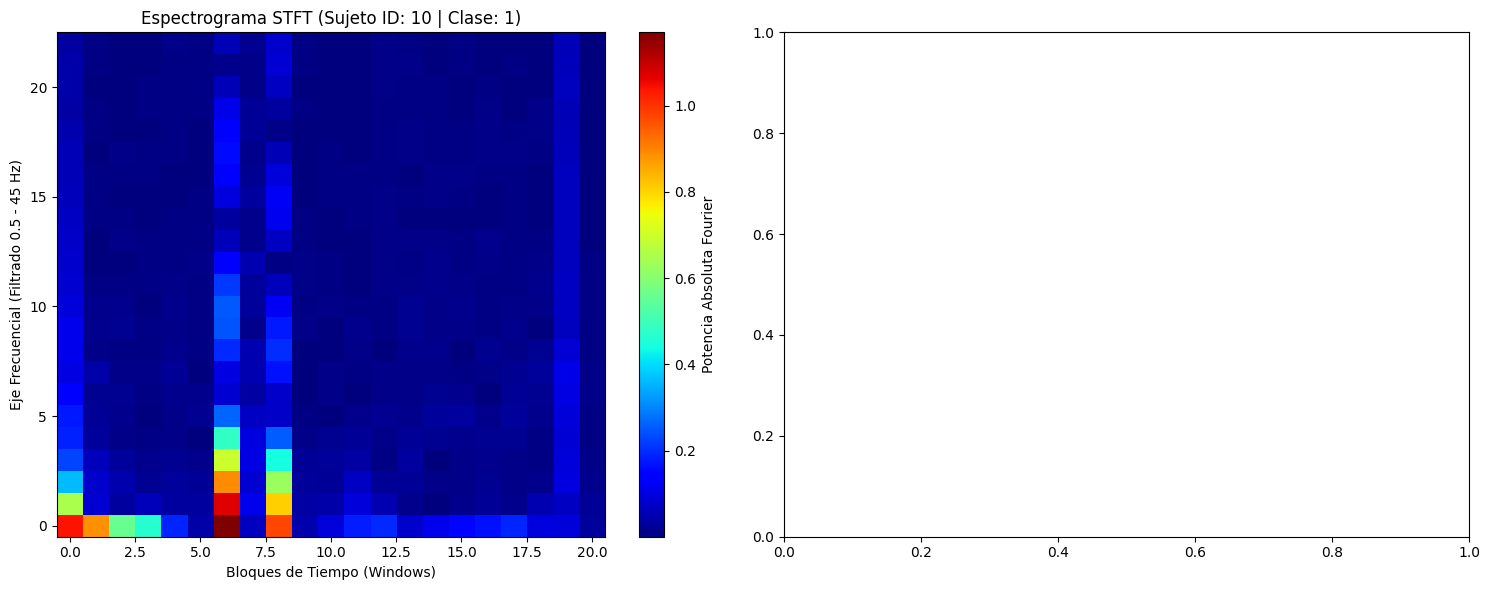

In [15]:
# =====================================================================
# 5. GENERACIÓN DE LA MUESTRA GRÁFICA (Guardado seguro en disco)
# =====================================================================
# Evaluamos visualmente el primer canal del primer paciente para el informe de Overleaf
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Graficar Espectrograma STFT
im0 = axs[0].imshow(X_stft[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
axs[0].set_title(f"Espectrograma STFT (Sujeto ID: {groups[0]} | Clase: {y[0]})")
axs[0].set_xlabel("Bloques de Tiempo (Windows)")
axs[0].set_ylabel("Eje Frecuencial (Filtrado 0.5 - 45 Hz)")
fig.colorbar(im0, ax=axs[0], label="Potencia Absoluta Fourier")

# Graficar Escalograma Wavelet (PyWavelets)
'''
im1 = axs[1].imshow(X_cwt[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
axs[1].set_title(f"Escalograma CWT PyWavelets (Sujeto ID: {groups[0]} | Clase: {y[0]})")
axs[1].set_xlabel("Muestras de Tiempo Continuas (Samples)")
axs[1].set_ylabel("Frecuencia Wavelet (0.5 - 45 Hz)")
fig.colorbar(im1, ax=axs[1], label="Magnitud de Coeficientes Morlet")
'''

plt.tight_layout()
# Guardamos la gráfica para evitar el comando interactivo plt.show() y asegurar reproducibilidad
plt.savefig("muestras_tiempo_frecuencia_eeg.pdf", dpi=300)
print("[✓] Gráfica de control de calidad visual exportada a 'muestras_tiempo_frecuencia_eeg.pdf'.")

### Fase 2 (cierre). Aplicar el split a las imágenes y normalizarlas

In [16]:
# =====================================================================
# 6. APLICAR EL SPLIT (YA HECHO EN FASE 1) AL TENSOR DE IMÁGENES STFT
# =====================================================================
# Usamos las mismas máscaras (train_mask/val_mask/test_mask) del split por
# sujeto de la Fase 1, así garantizamos que las imágenes de cada ventana
# caen en el mismo conjunto que su señal temporal correspondiente.
X_stft_train = X_stft[train_mask]
X_stft_val   = X_stft[val_mask]
X_stft_test  = X_stft[test_mask]

print(f"[OK] X_stft dividido -> train: {X_stft_train.shape} | val: {X_stft_val.shape} | test: {X_stft_test.shape}")


[OK] X_stft dividido -> train: (4333, 19, 23, 21) | val: (749, 19, 23, 21) | test: (864, 19, 23, 21)


In [17]:
# =====================================================================
# 7. NORMALIZACION DE LAS IMAGENES STFT (compresion log + z-score por canal)
# =====================================================================
# La magnitud de un espectrograma tiene un rango dinamico muy amplio (unos
# pocos bins concentran casi toda la energia), lo que dificulta el entrenamiento
# de una CNN. Aplicamos compresion logaritmica (log1p) y normalizamos con la
# media/desviacion calculadas SOLO en train (para no filtrar informacion de
# val/test), por canal, para mantener escalas comparables entre los 19 canales EEG.

X_stft_train_log = np.log1p(X_stft_train)
X_stft_val_log   = np.log1p(X_stft_val)
X_stft_test_log  = np.log1p(X_stft_test)

# Estadisticos por canal calculados unicamente con train
stft_mean = X_stft_train_log.mean(axis=(0, 2, 3), keepdims=True)
stft_std  = X_stft_train_log.std(axis=(0, 2, 3), keepdims=True) + 1e-8

X_stft_train_norm = (X_stft_train_log - stft_mean) / stft_std
X_stft_val_norm   = (X_stft_val_log   - stft_mean) / stft_std
X_stft_test_norm  = (X_stft_test_log  - stft_mean) / stft_std

print("[OK] Imagenes STFT normalizadas (log1p + z-score por canal, ajustado solo con train).")
print(f"    Rango train tras normalizacion: [{X_stft_train_norm.min():.2f}, {X_stft_train_norm.max():.2f}]")


[OK] Imagenes STFT normalizadas (log1p + z-score por canal, ajustado solo con train).
    Rango train tras normalizacion: [-0.92, 13.06]


## Fase 3. Extracción y selección de características clásicas (`tsfresh`)

> Si no tienes instalado `tsfresh`, corre `pip install tsfresh` antes de seguir.

In [18]:
# =====================================================================
# 1. IMPORTS PARA LA RAMA CLASICA (tsfresh)
# =====================================================================
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.utilities.dataframe_functions import impute

# [NOTA] Usamos MinimalFCParameters (~10 caracteristicas por canal) en vez de
# EfficientFCParameters (cientos de caracteristicas) porque con 19 canales y
# miles de ventanas, un set extenso es muy costoso en una maquina personal.
# Si tu hardware lo permite, puedes cambiar a EfficientFCParameters() despues
# y comparar si mejora el desempeno.
FC_PARAMETERS = MinimalFCParameters()
N_JOBS_TSFRESH = 0  # 0 = sin multiprocessing (mas estable en notebooks); sube este valor si tienes nucleos libres


In [19]:
# =====================================================================
# 2. FUNCION DE EXTRACCION tsfresh CANAL POR CANAL
# =====================================================================
def extract_tsfresh_features(X_split, channel_names, fc_parameters, n_jobs=0):
    """
    Extrae caracteristicas tsfresh CANAL POR CANAL (en vez de un unico
    dataframe largo multivariado) para mantener el uso de memoria bajo
    control: cada canal se procesa por separado y los resultados se
    concatenan horizontalmente, prefijando cada caracteristica con el
    nombre del canal de origen (ej. 'Fp1__mean', 'O2__variance').
    """
    n_windows, n_channels, n_samples = X_split.shape
    feature_blocks = []

    for ch_idx, ch_name in enumerate(channel_names):
        ids = np.repeat(np.arange(n_windows), n_samples)
        times = np.tile(np.arange(n_samples), n_windows)
        values = X_split[:, ch_idx, :].reshape(-1)
        df_long = pd.DataFrame({'id': ids, 'time': times, 'value': values})

        feats = extract_features(
            df_long, column_id='id', column_sort='time', column_value='value',
            default_fc_parameters=fc_parameters, n_jobs=n_jobs, disable_progressbar=True
        )
        feats = feats.add_prefix(f"{ch_name}__")
        feature_blocks.append(feats)
        print(f"    [{ch_idx + 1}/{n_channels}] Canal {ch_name} -> {feats.shape[1]} caracteristicas")

    return pd.concat(feature_blocks, axis=1)


In [20]:
# =====================================================================
# 3. EXTRACCION SOBRE TRAIN / VAL / TEST (puede tardar varios minutos)
# =====================================================================
print("[*] Extrayendo caracteristicas tsfresh -- TRAIN...")
feats_train_raw = extract_tsfresh_features(X_train, CANONICAL_CHANNELS, FC_PARAMETERS, N_JOBS_TSFRESH)

print("\n[*] Extrayendo caracteristicas tsfresh -- VAL...")
feats_val_raw = extract_tsfresh_features(X_val, CANONICAL_CHANNELS, FC_PARAMETERS, N_JOBS_TSFRESH)

print("\n[*] Extrayendo caracteristicas tsfresh -- TEST...")
feats_test_raw = extract_tsfresh_features(X_test, CANONICAL_CHANNELS, FC_PARAMETERS, N_JOBS_TSFRESH)

print(f"\n[OK] Caracteristicas extraidas por ventana: {feats_train_raw.shape[1]}")


[*] Extrayendo caracteristicas tsfresh -- TRAIN...
    [1/19] Canal Fp1 -> 10 caracteristicas
    [2/19] Canal Fp2 -> 10 caracteristicas
    [3/19] Canal F7 -> 10 caracteristicas
    [4/19] Canal F3 -> 10 caracteristicas
    [5/19] Canal Fz -> 10 caracteristicas
    [6/19] Canal F4 -> 10 caracteristicas
    [7/19] Canal F8 -> 10 caracteristicas
    [8/19] Canal T3 -> 10 caracteristicas
    [9/19] Canal C3 -> 10 caracteristicas
    [10/19] Canal Cz -> 10 caracteristicas
    [11/19] Canal C4 -> 10 caracteristicas
    [12/19] Canal T4 -> 10 caracteristicas
    [13/19] Canal T5 -> 10 caracteristicas
    [14/19] Canal P3 -> 10 caracteristicas
    [15/19] Canal Pz -> 10 caracteristicas
    [16/19] Canal P4 -> 10 caracteristicas
    [17/19] Canal T6 -> 10 caracteristicas
    [18/19] Canal O1 -> 10 caracteristicas
    [19/19] Canal O2 -> 10 caracteristicas

[*] Extrayendo caracteristicas tsfresh -- VAL...
    [1/19] Canal Fp1 -> 10 caracteristicas
    [2/19] Canal Fp2 -> 10 caracteristicas
   

In [21]:
# =====================================================================
# 4. IMPUTACION Y SELECCION DE CARACTERISTICAS (ajustada SOLO con train)
# =====================================================================
# tsfresh puede generar NaN/inf en senales casi constantes (ventanas con muy
# poca varianza); impute() las reemplaza con la mediana de cada columna.
impute(feats_train_raw)
impute(feats_val_raw)
impute(feats_test_raw)

# select_features usa pruebas de hipotesis (relevancia estadistica respecto a y)
# para descartar caracteristicas no informativas. Se ajusta SOLO con train para
# no filtrar informacion de val/test al elegir que caracteristicas conservar.
feats_train_selected = select_features(feats_train_raw, pd.Series(y_train))
selected_columns = feats_train_selected.columns

feats_val_selected  = feats_val_raw[selected_columns]
feats_test_selected = feats_test_raw[selected_columns]

print(f"[OK] Caracteristicas antes de seleccion: {feats_train_raw.shape[1]}")
print(f"[OK] Caracteristicas despues de seleccion: {feats_train_selected.shape[1]}")


[OK] Caracteristicas antes de seleccion: 190
[OK] Caracteristicas despues de seleccion: 112


## Fase 4a. Modelos clásicos (SVM, XGBoost, Random Forest, Regresión Logística)

In [22]:
# =====================================================================
# 1. FUNCION DE METRICAS REUTILIZABLE (clasicos y deep learning)
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, balanced_accuracy_score,
                              confusion_matrix)

def compute_metrics(y_true, y_pred, y_proba=None):
    """Calcula el set de metricas pedido por el proyecto: accuracy, precision,
    recall/sensibilidad, specificity, F1, balanced accuracy, ROC-AUC y matriz
    de confusion."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall_sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }

def print_metrics(name, metrics):
    print(f"[{name}] Acc={metrics['accuracy']:.3f} | F1={metrics['f1']:.3f} | "
          f"ROC-AUC={metrics['roc_auc']:.3f} | Sens={metrics['recall_sensitivity']:.3f} | "
          f"Spec={metrics['specificity']:.3f}")


In [23]:
# =====================================================================
# 2. ENTRENAMIENTO DE MODELOS CLASICOS (sobre las caracteristicas tsfresh seleccionadas)
# =====================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

RANDOM_STATE = 42

# Escalamos las caracteristicas (necesario para SVM/Regresion Logistica; no
# afecta a los modelos basados en arboles). El escalador se ajusta SOLO con train.
scaler = StandardScaler()
X_feat_train = scaler.fit_transform(feats_train_selected)
X_feat_val   = scaler.transform(feats_val_selected)
X_feat_test  = scaler.transform(feats_test_selected)

classical_models = {
    'SVM':               SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest':       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost':            XGBClassifier(n_estimators=300, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
}

classical_val_metrics = {}
fitted_classical_models = {}

for name, model in classical_models.items():
    model.fit(X_feat_train, y_train)
    y_pred_val = model.predict(X_feat_val)
    y_proba_val = model.predict_proba(X_feat_val)[:, 1]

    metrics = compute_metrics(y_val, y_pred_val, y_proba_val)
    classical_val_metrics[name] = metrics
    fitted_classical_models[name] = model
    print_metrics(name, metrics)


[SVM] Acc=0.761 | F1=0.761 | ROC-AUC=0.839 | Sens=0.866 | Spec=0.679
[RandomForest] Acc=0.837 | F1=0.836 | ROC-AUC=0.883 | Sens=0.945 | Spec=0.752
[XGBoost] Acc=0.829 | F1=0.825 | ROC-AUC=0.917 | Sens=0.918 | Spec=0.760
[LogisticRegression] Acc=0.709 | F1=0.704 | ROC-AUC=0.744 | Sens=0.787 | Spec=0.648


## Fase 4b. Modelos de deep learning (CNN propia y transfer learning) sobre espectrogramas STFT

Recomendación: tener las liberías de pytorch y cuda correctamente.

In [24]:
# =====================================================================
# 1. IMPORTS Y DATASET DE PYTORCH PARA LOS ESPECTROGRAMAS STFT
# =====================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo de entrenamiento: {device}")

class STFTDataset(Dataset):
    """Envuelve el tensor de espectrogramas (N, canales, freq, tiempo) y las
    etiquetas para usarlos con DataLoader de PyTorch."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32
train_loader = DataLoader(STFTDataset(X_stft_train_norm, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(STFTDataset(X_stft_val_norm, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(STFTDataset(X_stft_test_norm, y_test), batch_size=BATCH_SIZE, shuffle=False)


[INFO] Dispositivo de entrenamiento: cuda


In [25]:
# =====================================================================
# 2. FUNCIONES GENERICAS DE ENTRENAMIENTO Y EVALUACION (reutilizables para ambos modelos DL)
# =====================================================================
def train_model(model, train_loader, val_loader, n_epochs=20, lr=1e-3, patience=5):
    """Entrena con early stopping sobre la perdida de validacion. Devuelve el
    modelo con los mejores pesos encontrados en validacion."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb).squeeze(1)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"  Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  [INFO] Early stopping en epoch {epoch} (sin mejora en {patience} epocas).")
                break

    model.load_state_dict(best_state)
    return model


def evaluate_model(model, loader):
    """Corre el modelo en modo evaluacion y devuelve (y_true, y_pred, y_proba)."""
    model.eval()
    all_true, all_proba = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb).squeeze(1)
            proba = torch.sigmoid(logits).cpu().numpy()
            all_proba.extend(proba)
            all_true.extend(yb.numpy())
    all_true = np.array(all_true)
    all_proba = np.array(all_proba)
    all_pred = (all_proba >= 0.5).astype(int)
    return all_true, all_pred, all_proba


In [26]:
# =====================================================================
# 3. CNN PROPIA (arquitectura base entrenada desde cero)
# =====================================================================
class SimpleEEGCNN(nn.Module):
    """CNN pequena que toma el espectrograma multicanal (19 canales EEG,
    freq, tiempo) tratando los 19 canales como la dimension de 'canales de
    imagen' (analogo a RGB pero con 19 canales)."""
    def __init__(self, n_channels=19):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(n_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)

print("[*] Entrenando CNN propia...")
cnn_model = SimpleEEGCNN(n_channels=len(CANONICAL_CHANNELS))
cnn_model = train_model(cnn_model, train_loader, val_loader, n_epochs=30, lr=1e-3, patience=6)

y_val_true, y_val_pred, y_val_proba = evaluate_model(cnn_model, val_loader)
cnn_val_metrics = compute_metrics(y_val_true, y_val_pred, y_val_proba)
print_metrics("CNN propia", cnn_val_metrics)


[*] Entrenando CNN propia...
  Epoch 01 | train_loss=0.5085 | val_loss=0.5369
  Epoch 02 | train_loss=0.3822 | val_loss=0.5578
  Epoch 03 | train_loss=0.3221 | val_loss=0.5372
  Epoch 04 | train_loss=0.2860 | val_loss=0.6775
  Epoch 05 | train_loss=0.2799 | val_loss=0.7905
  Epoch 06 | train_loss=0.2456 | val_loss=0.8832
  Epoch 07 | train_loss=0.2200 | val_loss=0.7735
  [INFO] Early stopping en epoch 7 (sin mejora en 6 epocas).
[CNN propia] Acc=0.758 | F1=0.754 | ROC-AUC=0.806 | Sens=0.842 | Spec=0.693


In [27]:
# =====================================================================
# 4. RESNET18 CON TRANSFER LEARNING (adaptado a 19 canales de entrada)
# =====================================================================
# ResNet18 viene preentrenado con imagenes RGB (3 canales) de ~224x224.
# Reemplazamos su primera convolucion para aceptar 19 canales, inicializando
# los pesos nuevos como el promedio de los 3 filtros RGB originales repetido
# 19 veces (conservamos parte del conocimiento preentrenado en vez de partir
# de cero). Tambien redimensionamos el espectrograma a 64x64 antes de entrar
# a la red: sin esto, el downsampling agresivo de ResNet reduciria nuestras
# imagenes (23x21) a un tamano degenerado de 1x1 en pocas capas.
import torchvision.models as tv_models

def build_resnet18_for_eeg(n_channels):
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)

    old_conv = model.conv1
    new_conv = nn.Conv2d(n_channels, old_conv.out_channels,
                          kernel_size=old_conv.kernel_size,
                          stride=old_conv.stride,
                          padding=old_conv.padding,
                          bias=False)
    with torch.no_grad():
        avg_weight = old_conv.weight.mean(dim=1, keepdim=True)  # promedio sobre los 3 canales RGB
        new_conv.weight[:] = avg_weight.repeat(1, n_channels, 1, 1)
    model.conv1 = new_conv
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model


class ResNetEEGWrapper(nn.Module):
    """Redimensiona el espectrograma a una resolucion mas adecuada para una
    arquitectura disenada para imagenes mas grandes."""
    def __init__(self, base_model, target_size=(64, 64)):
        super().__init__()
        self.base_model = base_model
        self.target_size = target_size

    def forward(self, x):
        x = F.interpolate(x, size=self.target_size, mode='bilinear', align_corners=False)
        return self.base_model(x)


print("[*] Entrenando ResNet18 (transfer learning, conv1 adaptada a 19 canales)...")
resnet_model = ResNetEEGWrapper(build_resnet18_for_eeg(n_channels=len(CANONICAL_CHANNELS)))
resnet_model = train_model(resnet_model, train_loader, val_loader, n_epochs=20, lr=1e-4, patience=5)

y_val_true, y_val_pred, y_val_proba = evaluate_model(resnet_model, val_loader)
resnet_val_metrics = compute_metrics(y_val_true, y_val_pred, y_val_proba)
print_metrics("ResNet18 (transfer)", resnet_val_metrics)


[*] Entrenando ResNet18 (transfer learning, conv1 adaptada a 19 canales)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/germain/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:31<00:00, 1.49MB/s]


  Epoch 01 | train_loss=0.5070 | val_loss=0.4482
  Epoch 02 | train_loss=0.3109 | val_loss=0.4398
  Epoch 03 | train_loss=0.2088 | val_loss=0.3871
  Epoch 04 | train_loss=0.1608 | val_loss=0.6315
  Epoch 05 | train_loss=0.1374 | val_loss=0.4284
  Epoch 06 | train_loss=0.1411 | val_loss=0.5709
  Epoch 07 | train_loss=0.1059 | val_loss=0.6255
  Epoch 08 | train_loss=0.1012 | val_loss=0.4947
  [INFO] Early stopping en epoch 8 (sin mejora en 5 epocas).
[ResNet18 (transfer)] Acc=0.814 | F1=0.801 | ROC-AUC=0.903 | Sens=0.848 | Spec=0.788


## Fase 5. Comparación experimental final (evaluación en TEST)

In [28]:
# =====================================================================
# 1. EVALUACION FINAL DE TODOS LOS MODELOS SOBRE EL CONJUNTO DE TEST
# =====================================================================
# Hasta ahora usamos VAL para monitorear entrenamiento/seleccion de modelos.
# El conjunto TEST se reserva para esta unica evaluacion final, nunca antes.

final_results = {}

# Modelos clasicos
for name, model in fitted_classical_models.items():
    y_pred = model.predict(X_feat_test)
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    final_results[name] = compute_metrics(y_test, y_pred, y_proba)

# Modelos deep learning
y_true_cnn, y_pred_cnn, y_proba_cnn = evaluate_model(cnn_model, test_loader)
final_results['CNN propia'] = compute_metrics(y_true_cnn, y_pred_cnn, y_proba_cnn)

y_true_resnet, y_pred_resnet, y_proba_resnet = evaluate_model(resnet_model, test_loader)
final_results['ResNet18 (transfer)'] = compute_metrics(y_true_resnet, y_pred_resnet, y_proba_resnet)

for name, metrics in final_results.items():
    print_metrics(name, metrics)


[SVM] Acc=0.663 | F1=0.667 | ROC-AUC=0.742 | Sens=0.772 | Spec=0.579
[RandomForest] Acc=0.686 | F1=0.695 | ROC-AUC=0.746 | Sens=0.820 | Spec=0.583
[XGBoost] Acc=0.697 | F1=0.697 | ROC-AUC=0.693 | Sens=0.798 | Spec=0.618
[LogisticRegression] Acc=0.693 | F1=0.699 | ROC-AUC=0.729 | Sens=0.814 | Spec=0.600
[CNN propia] Acc=0.704 | F1=0.714 | ROC-AUC=0.778 | Sens=0.846 | Spec=0.593
[ResNet18 (transfer)] Acc=0.683 | F1=0.686 | ROC-AUC=0.700 | Sens=0.793 | Spec=0.598


In [29]:
# =====================================================================
# 2. TABLA COMPARATIVA FINAL
# =====================================================================
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': m['accuracy'],
        'Precision': m['precision'],
        'Sensibilidad (Recall)': m['recall_sensitivity'],
        'Especificidad': m['specificity'],
        'F1-score': m['f1'],
        'Balanced Accuracy': m['balanced_accuracy'],
        'ROC-AUC': m['roc_auc'],
    }
    for name, m in final_results.items()
}).T.sort_values('F1-score', ascending=False)

print(comparison_df.round(3))
comparison_df.to_csv('comparacion_final_modelos.csv')
print("\n[OK] Tabla guardada en 'comparacion_final_modelos.csv'")


                     Accuracy  Precision  Sensibilidad (Recall)  \
CNN propia              0.704      0.617                  0.846   
LogisticRegression      0.693      0.612                  0.814   
XGBoost                 0.697      0.618                  0.798   
RandomForest            0.686      0.604                  0.820   
ResNet18 (transfer)     0.683      0.604                  0.793   
SVM                     0.663      0.587                  0.772   

                     Especificidad  F1-score  Balanced Accuracy  ROC-AUC  
CNN propia                   0.593     0.714              0.720    0.778  
LogisticRegression           0.600     0.699              0.707    0.729  
XGBoost                      0.618     0.697              0.708    0.693  
RandomForest                 0.583     0.695              0.701    0.746  
ResNet18 (transfer)          0.598     0.686              0.695    0.700  
SVM                          0.579     0.667              0.675    0.742  

[OK]

[OK] Matrices de confusion exportadas a 'matrices_confusion_finales.pdf'


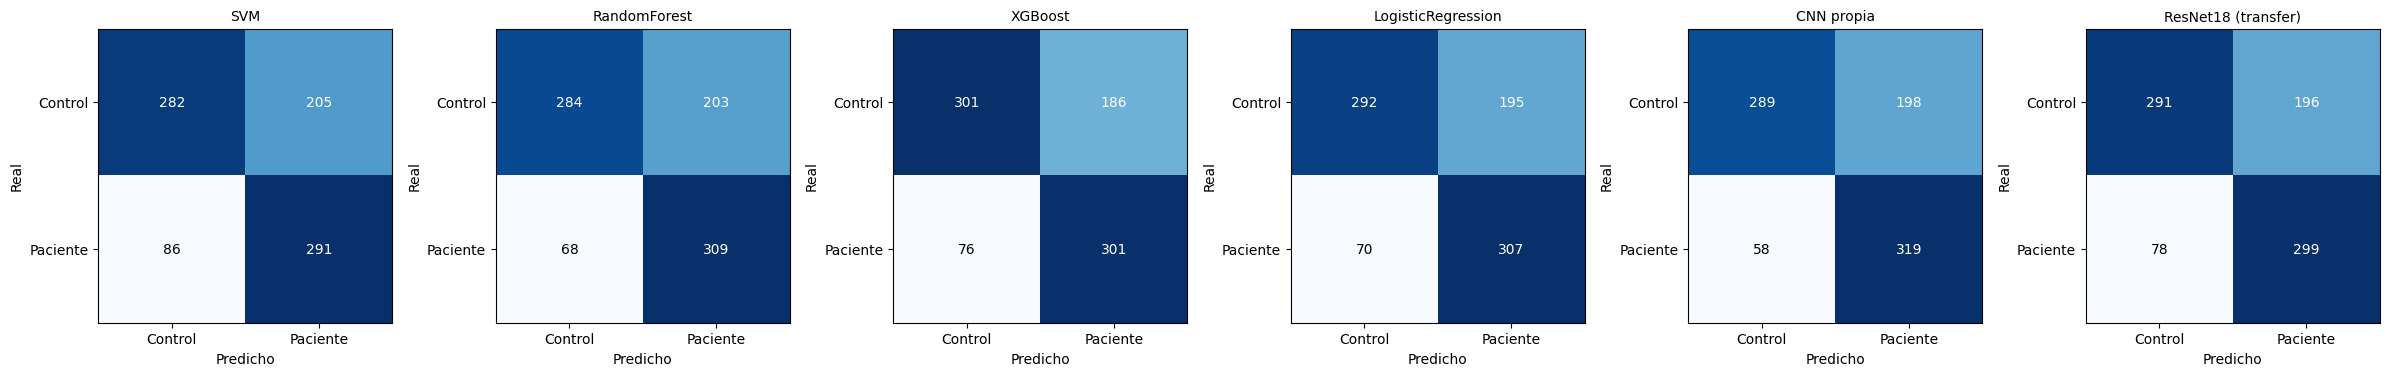

In [30]:
# =====================================================================
# 3. MATRICES DE CONFUSION DE TODOS LOS MODELOS
# =====================================================================
n_models = len(final_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, metrics) in zip(axes, final_results.items()):
    cm = np.array(metrics['confusion_matrix'])
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Control', 'Paciente'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Control', 'Paciente'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.savefig('matrices_confusion_finales.pdf', dpi=300)
print("[OK] Matrices de confusion exportadas a 'matrices_confusion_finales.pdf'")


## Conclusiones

*(completar después de ver los resultados de la Fase 5: qué enfoque ganó — características tsfresh + ML clásico vs. imágenes tiempo-frecuencia + deep learning —, con qué métrica y margen, y si responde a la pregunta del objetivo del proyecto.)*

Esperar a los resultados, interpretar, ablation y discusión previamente :D